# Ableton Project Notebook

### Notebook Runtime

##### Updated 11/2024

#### Local
* should work with same python3 environment as parse_projects.py 

#### Colab:
* run `./ableton_projects/start_notebook.sh` to start
server on `8888`
* see `start_notebook.sh` for installing python2 kernel and packages
* see https://research.google.com/colaboratory/local-runtimes.html


### Modules

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
import parse_projects as parser
print(f"Python Version:\n  {parser.PYTHON_VERSION}")


Python Version:
  3.13.0 (main, Oct  7 2024, 05:02:14) [Clang 16.0.0 (clang-1600.0.26.4)]


### Load Parsed Projects

In [15]:
#@title Get info for all Projects and cache

# Load projects using default args should work if notebook is in project dir.
load_most_recent_cached = True #@param {type:"boolean"}
project_dir = "./" #@param {type:"string"}
# Overwrite parser defaults
# SKIP_FOLDERS = [ 'Backup', 'old', 'Samples', 'Ableton Project Info', '.git'] #@param {type:"raw"}
# CACHE_DIR = "./logs/" #@param {type:"string"}


# Load from recent cache (fast)
if load_most_recent_cached: 
  project_info = parser.load_info(prefix=parser.CACHE_INFO_FILE, load_most_recent=True)
  project_errors = parser.load_info(prefix=parser.CACHE_ERROR_FILE, load_most_recent=True)

# Parse project .als files
else:
  project_info, project_errors = parser.run_parser(project_dir)

if len(project_errors):
  print('Projects missing info due to errors')
  pprint(project_errors)

Loading project_info from 2024-11-29 01:24:54.
Loaded 466 project_info in 0.01 seconds.
Loading project_errors from 2024-11-29 00:51:59.
Loaded 6 project_errors in 0.00 seconds.
Projects missing info due to errors
{'1 legacy': TypeError("int() argument must be a string, a bytes-like object or a real number, not 'NoneType'"),
 '2 legacy': TypeError("int() argument must be a string, a bytes-like object or a real number, not 'NoneType'"),
 '3 legacy': TypeError("int() argument must be a string, a bytes-like object or a real number, not 'NoneType'"),
 '4 legacy': TypeError("int() argument must be a string, a bytes-like object or a real number, not 'NoneType'"),
 '5 legacy': TypeError("int() argument must be a string, a bytes-like object or a real number, not 'NoneType'"),
 '6 + 7 legacy': TypeError("int() argument must be a string, a bytes-like object or a real number, not 'NoneType'")}


#### TODO: fix errors and some projects have skipped tracks (see above)

Are these all ableton 12, should i convert to 11? hopw to support 12 too (add _12)

```
 READING: dark rav vox rodas
  SKIPPING None track 8
 READING: lekato loops
  SKIPPING None track 8
 READING: chill guitar beats lekato
  SKIPPING None track 31
 READING: anotert
  SKIPPING None track 8
 READING: template 12
  SKIPPING None track 6
 READING: raw outdoor porch  *** guitarbeet/mac_work start here most simple project
  SKIPPING None track 4
 READING: acoustic lofi mac  jam
  SKIPPING None track 6
 READING: vox acoustic
  SKIPPING None track 8
 READING: summa time
  SKIPPING None track 14
 READING: dubler vox pick
  SKIPPING None track 4
 
```

In [ ]:
for p, info in project_info.items():
    if 'lekato' in p:
        print(p)
        pprint(info)

# Analysis

1000 least used vst plugins:
Guitar Rig 5                 396
iZotope Ozone 5              183
Maschine 2                   182
Komplete Kontrol             144
Solid Bus Comp                44
Reaktor 6 FX                  42
Ozone Pro                     29
Toraverb                      28
TAL-Chorus-LX                 21
Dirt                          18
Guitar Rig 6                  18
iZotope Alloy 2               17
Tal-Chorus-LX                 16
GS-201                        10
iZotope Stutter Edit           9
ValhallaRoom                   8
AmpliTube 4                    8
iZotope Ozone 5 Reverb         7
Zebra2                         6
iZotope Ozone 5 Imager         6
Drumazon                       5
Driver                         5
iZotope Nectar 2               4
Microtonic                     4
Phoscyon                       3
RC 24                          3
iZotope Insight                3
Neutron 3                      3
iZotope Ozone 5 Equalizer      3
TAL-U-No-62   

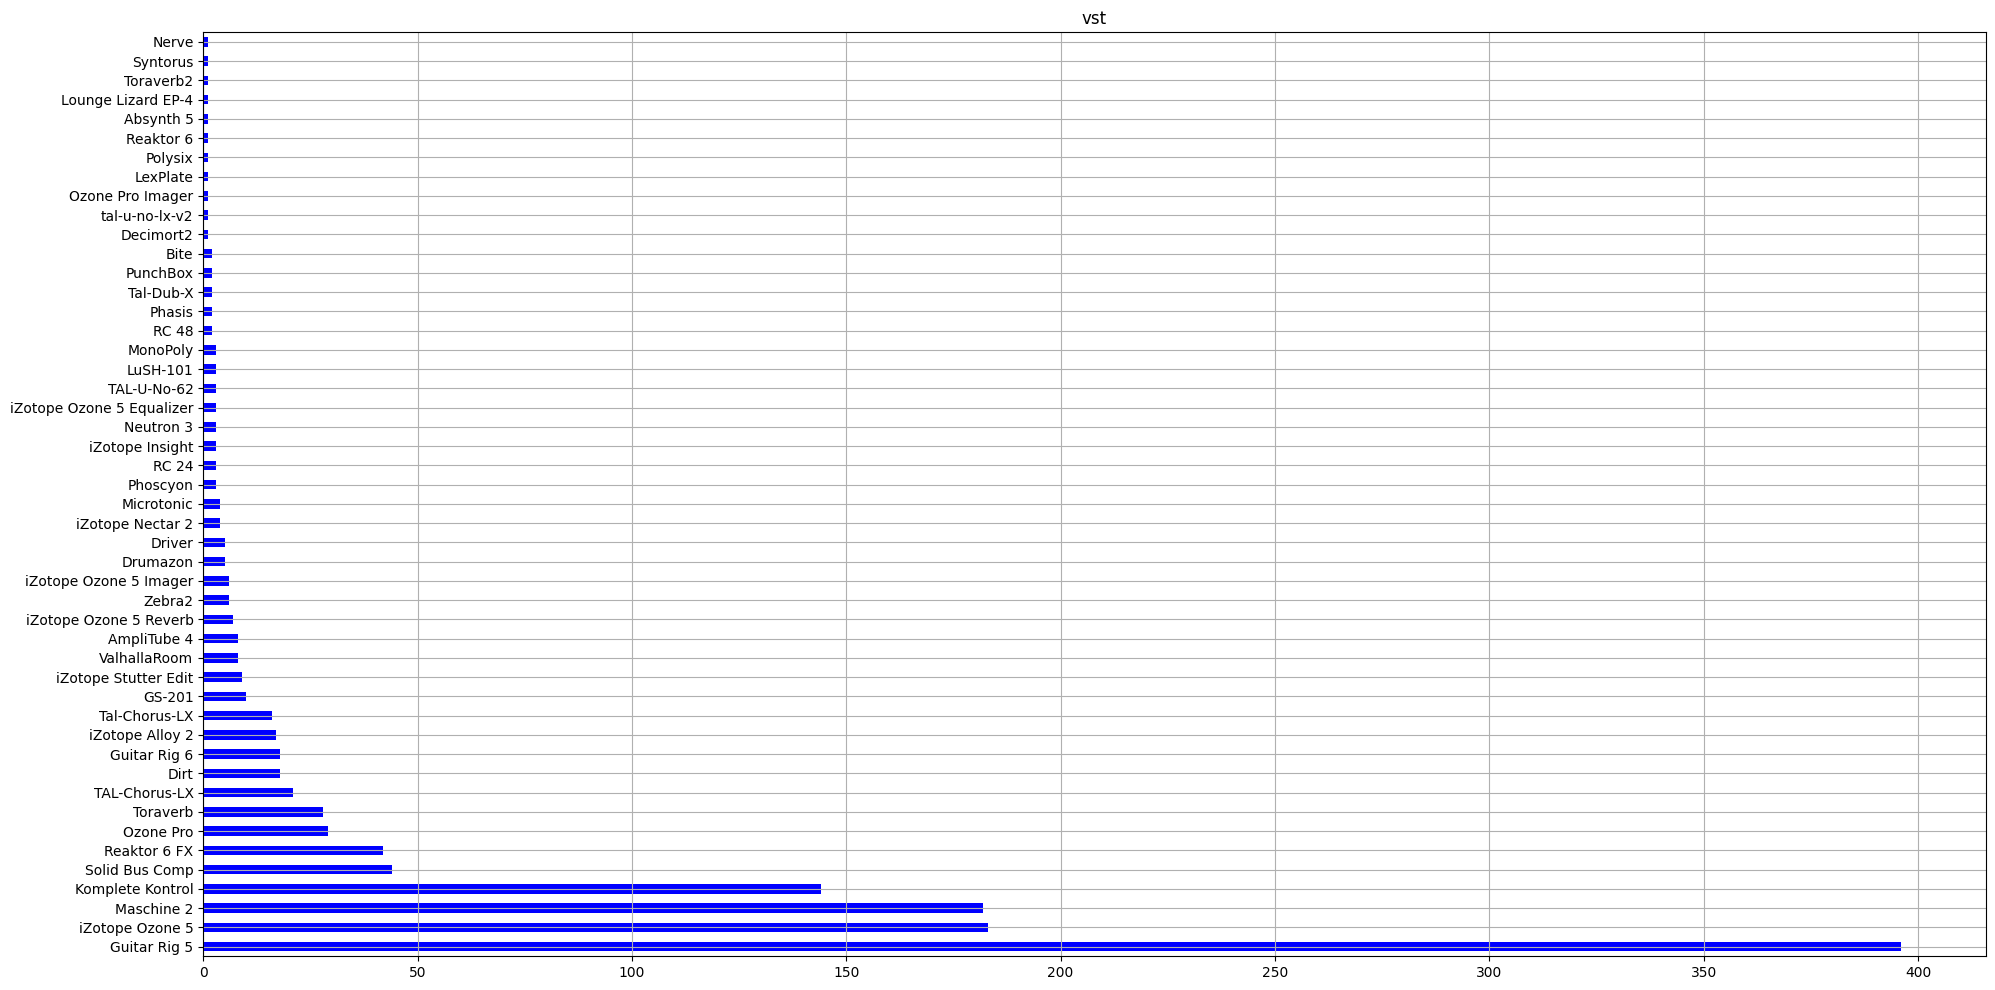

1000 least used audio_unit plugins:
GS-201              36
Neutron 4           23
Crystallizer         3
iZotope Nectar 2     3
Massive              2
iZotope Ozone 5      1
Komplete Kontrol     1
Maschine 2           1
Name: count, dtype: int64


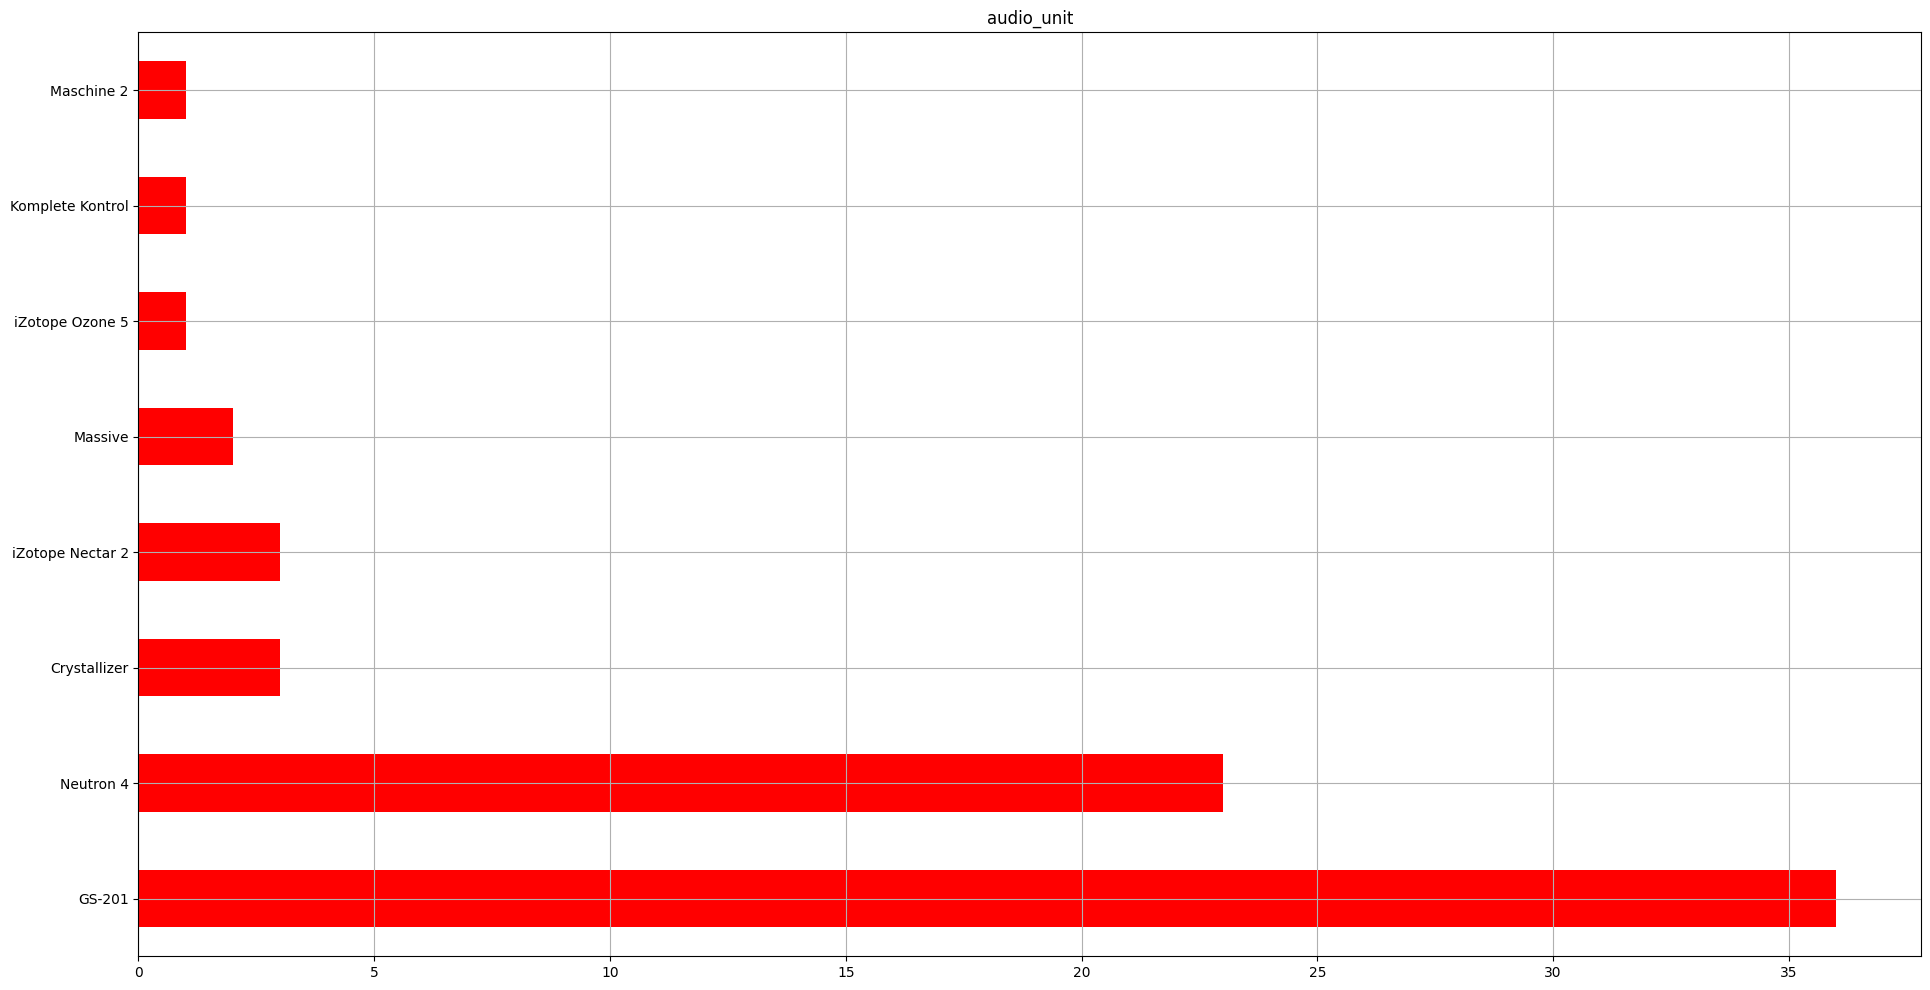

In [13]:
#@title Show VST and AU usage

def get_plugin_usage(project_info):
  plugins = {'vst': [], 'audio_unit': [], 'ableton': []}
  for fname, v in project_info.items():
    for track in v['tracks']:
      for dev in track['devices']:
        if dev['type'] == 'PluginDevice': # for vsts
          plugins['vst'].append(dev['preset'])
        elif dev['type'] == 'AuPluginDevice':  # for audiounits
          plugins['audio_unit'].append(dev['preset'])
        else:  # for default ableton plugin
          plugins['ableton'].append(dev['type'])
  plugins_usage = {k: pd.Series(v).value_counts() for k,v in plugins.items()}
  return plugins_usage

# Show histogram of plugins
skip_keys = ['ableton']
colors = ['green', 'red', 'blue']
n=1000
plugins = get_plugin_usage(project_info)
for key in plugins.keys():
  if key in skip_keys:
    continue
  print('%d least used %s plugins:\n%s' % (n, key, plugins[key][-n:]))
  plugins[key].plot.barh(figsize=(23, 12), grid=True, color=colors.pop(), title=key)
  plt.show()

In [ ]:
def query_projects_by_plugin(project_info, plugin_type, preset_name):
  project_keys = []
  assert plugin_type in ['PluginDevice', 'AuPluginDevice']
  for fname, v in project_info.items():
    for track in v['tracks']:
      for dev in track['devices']:
        if dev['type'] == plugin_type and dev['preset'] == preset_name:
            project_keys.append('%s-%d' % (fname, track['index']))

  return project_keys

query_projects_by_plugin(project_info, "PluginDevice", "Neutron 3")

['_acoustic jams sorted-33', '_two track jams-31', 'house acoustic jam-1']

In [11]:
#@title Some checks
DEPRECATED_PLUGINS = ["Ozone 8", "Ozone 6"] # "Neutron 3"
for vst in DEPRECATED_PLUGINS:
  print(f'CHECK\t| {vst} should not be an any projects', end='')
  assert 0 == len(query_projects_by_plugin(project_info, "PluginDevice", vst))
  print('...and is not')

ONLY_A10_AUDIO_UNIT = ['Crystallizer', 'GS-201']
for au in ONLY_A10_AUDIO_UNIT:
  print(f'NOTE\t| {au} is only available as a 32 bit audio unit')


CHECK	| Ozone 8 should not be an any projects...and is not
CHECK	| Ozone 6 should not be an any projects...and is not
NOTE	| Crystallizer is only available as a 32 bit audio unit
NOTE	| GS-201 is only available as a 32 bit audio unit


#### TODO: FIX Audiounit plugins
* dimensions 4: on a10, swap out iZotope Ozone 5 AU for VST
* slow burn mixdown: swap out Maschine 2 and Komplete Kontrol AU for VST
* brady-jake jam +extra day 2: swap out Massive AU for VST
* brady-jake jam 0: swap out Massive AU for VST
* acoustic sad vox (multiple): swap out iZotope Nectar 2 AU for VST

**TODO**:add above check that the only 2 audiounites are ONLY_A10_AUDIO_UNIT


In [12]:
#@title Query
plugin_type = "PluginDevice" #@param ["PluginDevice", "AuPluginDevice"]
preset_name = "Reaktor 6 FX" #@param {type:"string"}

projects = query_projects_by_plugin(project_info,
    plugin_type=plugin_type,
    preset_name=preset_name
)

print('Projects matching preset: %s\n' % preset_name)
for p in sorted(projects):
  print(p)

Projects matching preset: Reaktor 6 FX

2021 mac13 template-1
2021 mac13 template-2
MORE of a jam-10
NEW YTEMPLATE-2
a-1
a-2
aciustic mac feedback-1
aciustic mac feedback-2
acoustic jam psych-1
acoustrunkv2-2
acoustrunkv2-3
acoustrunkv2-4
acoustrunkv2-5
acoustrunkvo-1
acoustrunkvo-2
autotune sad minor guitar-3
bnchmark-1
bnchmark-2
current template-2
death flutes-6
garage rock template-3
guitar live-1
guitar vox loops downmixed-1
guitar vox loops downmixed-2
guitar vox loops-1
guitar vox loops-2
hipohopy-1
hipohopy-2
loose acousitc distorted vox loop jam-1
makings of a jam-2
new roume jaamz-1
psychccy acoust trip loops-3
sad verse psych-1
sad verse psych-2
single trackpyshch new roume accoustic blah-1
slow dark garage jaaam-3
soul sample-3
template_2020 2-1
template_2020 2-2
template_2020-1
template_2020-2
traoppy-6


In [13]:
#@title Audio Unit Query
plugin_type = "AuPluginDevice" #@param ["PluginDevice", "AuPluginDevice"]
preset_name = "GS-201" #@param {type:"string"}

projects = query_projects_by_plugin(project_info,
    plugin_type=plugin_type,
    preset_name=preset_name
)

print('Projects matching preset: %s\n' % preset_name)
for p in sorted(projects):
  print(p)

Projects matching preset: GS-201

1-27
3-7
4-22
461-6
5-14
5-15
Blazed Electric Guitar recorded-8
Dance Beat [Loops]-7
Dowm Chill 'vErB up-14
Downtime Chill Vibe-6
Green the color-8
Maggots Chill-5
SpokoACIDsampler [song] [unmxd]-10
b itch gowsays [Loops]-3
b itch gowsays [Loops]-7
dimension live remix 2-7
dimension live remix 2-9
hazzy chill-7
high vox loops-2
high vox loops-3
high vox loops-5
high vox loops-7
jarryork 23-5
jarryork-5
loaunge chill j a10 gsi-8
lofi accoustic psych-7
new bumpabumb-15
psych guiTarr beat-2
psych guiTarr beat-4
something-7
surff classicaL sh-3
trippy vox loops-2
trippy vox loops-3
trippy vox loops-5
trippy vox loops-7
watching fish-11
